# DCGAN — CelebA Face Generation
**Research-Quality Implementation**
- Architecture: DCGAN (Radford et al., 2015)
- Dataset: CelebA aligned faces
- Target: Realistic 64×64 face images
- Expected: G loss decreases, D loss stays balanced (~0.5–1.5 range)

In [17]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

In [ ]:

IMG_DIR   = "/content/drive/MyDrive/GAN_CelebA/img_align_celeba"
SAVE_DIR  = "/content/drive/MyDrive/GAN_CelebA/samples"
MODEL_DIR = "/content/drive/MyDrive/GAN_CelebA/models"

os.makedirs(SAVE_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:

Z_DIM      = 100
IMG_SIZE   = 64
BATCH_SIZE = 120
EPOCHS     = 250
LR_G       = 2e-4
LR_D       = 2e-4
BETA_1     = 0.5
N_CRITIC   = 1

In [ ]:

dataset = tf.keras.utils.image_dataset_from_directory(
    IMG_DIR,
    labels=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)


dataset = dataset.map(
    lambda x: (tf.cast(x, tf.float32) / 127.5) - 1.0,
    num_parallel_calls=tf.data.AUTOTUNE
)
dataset = dataset.cache().prefetch(tf.data.AUTOTUNE)

print("Dataset ready.")

In [ ]:

def build_generator():
    model = tf.keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(Z_DIM,)))
    model.add(layers.Dense(4 * 4 * 1024, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((4, 4, 1024)))

    # 4 → 8
    model.add(layers.Conv2DTranspose(512, kernel_size=4, strides=2,
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 8 → 16
    model.add(layers.Conv2DTranspose(256, kernel_size=4, strides=2,
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 16 → 32
    model.add(layers.Conv2DTranspose(128, kernel_size=4, strides=2,
                                     padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 32 → 64
    model.add(layers.Conv2DTranspose(3, kernel_size=4, strides=2,
                                     padding='same', use_bias=False,
                                     activation='tanh'))

    return model


def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

    # 64 → 32
    model.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same',
                             use_bias=False))
    model.add(layers.LeakyReLU(0.2))

    # 32 → 16
    model.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same',
                             use_bias=False))
    model.add(layers.LayerNormalization())
    model.add(layers.LeakyReLU(0.2))

    # 16 → 8
    model.add(layers.Conv2D(256, kernel_size=4, strides=2, padding='same',
                             use_bias=False))
    model.add(layers.LayerNormalization())
    model.add(layers.LeakyReLU(0.2))

    # 8 → 4
    model.add(layers.Conv2D(512, kernel_size=4, strides=2, padding='same',
                             use_bias=False))
    model.add(layers.LayerNormalization())
    model.add(layers.LeakyReLU(0.2))

    # Scalar logit
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


generator     = build_generator()
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

In [23]:

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_logits, fake_logits):
    """D wants: real → 1, fake → 0"""
    real_labels = tf.ones_like(real_logits) * 0.9   # one-sided label smoothing
    fake_labels = tf.zeros_like(fake_logits)
    loss_real = cross_entropy(real_labels, real_logits)
    loss_fake = cross_entropy(fake_labels, fake_logits)
    return loss_real + loss_fake


def generator_loss(fake_logits):
    """G wants discriminator to think fake → 1 (non-saturating loss)"""
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

In [24]:

g_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_G, beta_1=BETA_1)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_D, beta_1=BETA_1)

In [25]:

@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise      = tf.random.normal([batch_size, Z_DIM])


    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)
        d_loss      = discriminator_loss(real_logits, fake_logits)

    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))


    noise = tf.random.normal([batch_size, Z_DIM])
    with tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)
        fake_logits = discriminator(fake_images, training=True)
        g_loss      = generator_loss(fake_logits)

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return g_loss, d_loss

In [26]:

fixed_noise = tf.random.normal([16, Z_DIM])


def save_sample_grid(epoch):
    """Generate 4×4 grid of faces and save to disk."""
    imgs = generator(fixed_noise, training=False)
    imgs = (imgs.numpy() + 1.0) / 2.0   # [-1,1] → [0,1]
    imgs = np.clip(imgs, 0.0, 1.0)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(f"Epoch {epoch}", fontsize=14, y=1.01)

    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i])
        ax.axis("off")

    plt.tight_layout()
    path = os.path.join(SAVE_DIR, f"epoch_{epoch:03d}.png")
    plt.savefig(path, bbox_inches='tight', dpi=100)
    plt.show()
    print(f"  Samples saved → {path}")

Starting training...

Epoch   1/250 | G_loss: 6.9760 | D_loss: 1.1821 | Time: 73.7s


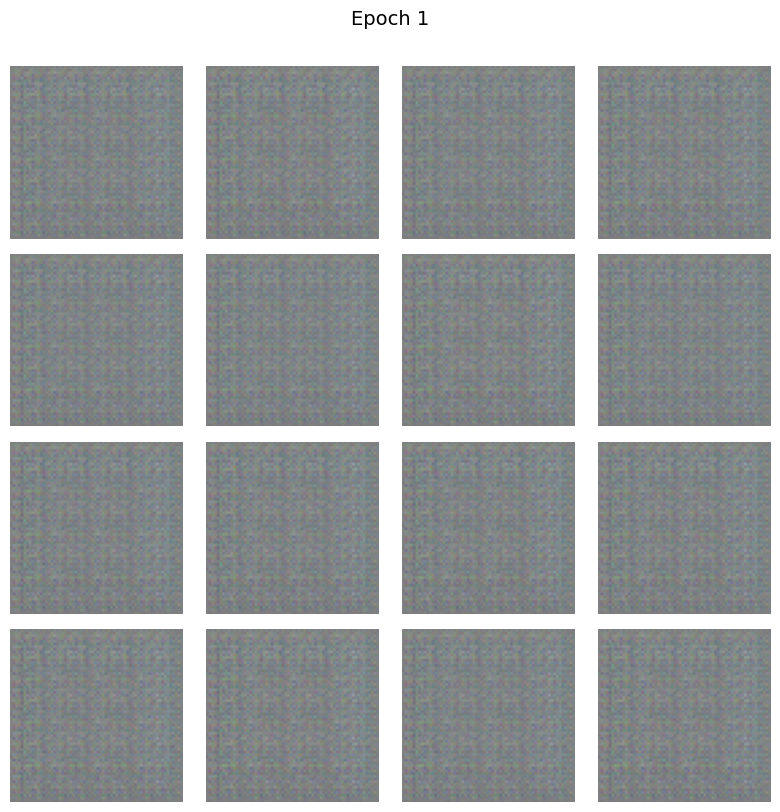

  Samples saved → /content/drive/MyDrive/GAN_CelebA/samples/epoch_001.png
Epoch   2/250 | G_loss: 4.0087 | D_loss: 0.6101 | Time: 19.0s


In [ ]:
g_loss_history = []
d_loss_history = []


def train(dataset, epochs):
    print("Starting training...\n")

    for epoch in range(1, epochs + 1):
        t_start  = time.time()
        g_losses = []
        d_losses = []

        for real_batch in dataset:
            g_loss, d_loss = train_step(real_batch)
            g_losses.append(float(g_loss))
            d_losses.append(float(d_loss))

        avg_g = np.mean(g_losses)
        avg_d = np.mean(d_losses)

        g_loss_history.append(avg_g)
        d_loss_history.append(avg_d)

        elapsed = time.time() - t_start
        print(f"Epoch {epoch:3d}/{epochs} "
              f"| G_loss: {avg_g:.4f} "
              f"| D_loss: {avg_d:.4f} "
              f"| Time: {elapsed:.1f}s")

        # Save grid every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            save_sample_grid(epoch)

        # Save model every 10 epochs
        if epoch % 10 == 0:
            ckpt_path = os.path.join(MODEL_DIR, f"generator_epoch{epoch:03d}.keras")
            generator.save(ckpt_path)
            print(f"  Checkpoint saved → {ckpt_path}")

    # Save final models and loss histories
    final_gen_path = os.path.join(MODEL_DIR, "generator_final.keras")
    generator.save(final_gen_path)
    print(f"\nFinal generator model saved → {final_gen_path}")

    final_disc_path = os.path.join(MODEL_DIR, "discriminator_final.keras")
    discriminator.save(final_disc_path)
    print(f"Final discriminator model saved → {final_disc_path}")

    np.save(os.path.join(MODEL_DIR, "g_loss.npy"), g_loss_history)
    np.save(os.path.join(MODEL_DIR, "d_loss.npy"), d_loss_history)
    print(f"Loss histories saved to {MODEL_DIR}")

train(dataset, EPOCHS)


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/GAN_Models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [14]:
epoch = EPOCHS
ckpt_path = os.path.join(MODEL_DIR, f"generator_epoch{epoch:03d}.keras")
generator.save(ckpt_path)
final_path = os.path.join(MODEL_DIR, "generator_final.keras")
generator.save(final_path)
discriminator.save(os.path.join(MODEL_DIR, f"discriminator_epoch{epoch:03d}.keras"))
np.save(os.path.join(MODEL_DIR, "g_loss.npy"), g_loss_history)
np.save(os.path.join(MODEL_DIR, "d_loss.npy"), d_loss_history)


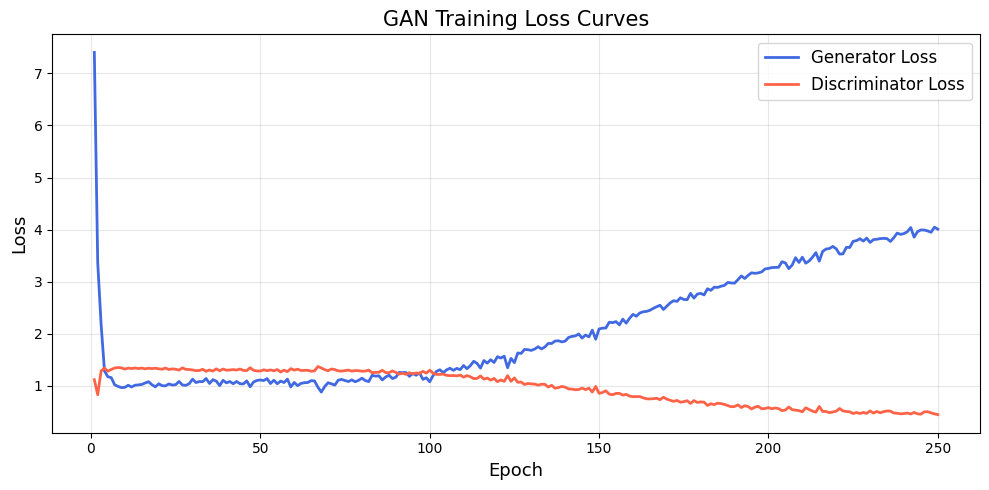

Loss curves saved → /content/drive/MyDrive/GAN_CelebA/samples/loss_curves.png


In [15]:

epochs_range = range(1, len(g_loss_history) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs_range, g_loss_history, label='Generator Loss',
        color='royalblue', linewidth=2)
ax.plot(epochs_range, d_loss_history, label='Discriminator Loss',
        color='tomato', linewidth=2)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('GAN Training Loss Curves', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
loss_path = os.path.join(SAVE_DIR, "loss_curves.png")
plt.savefig(loss_path, dpi=150)
plt.show()
print(f"Loss curves saved → {loss_path}")

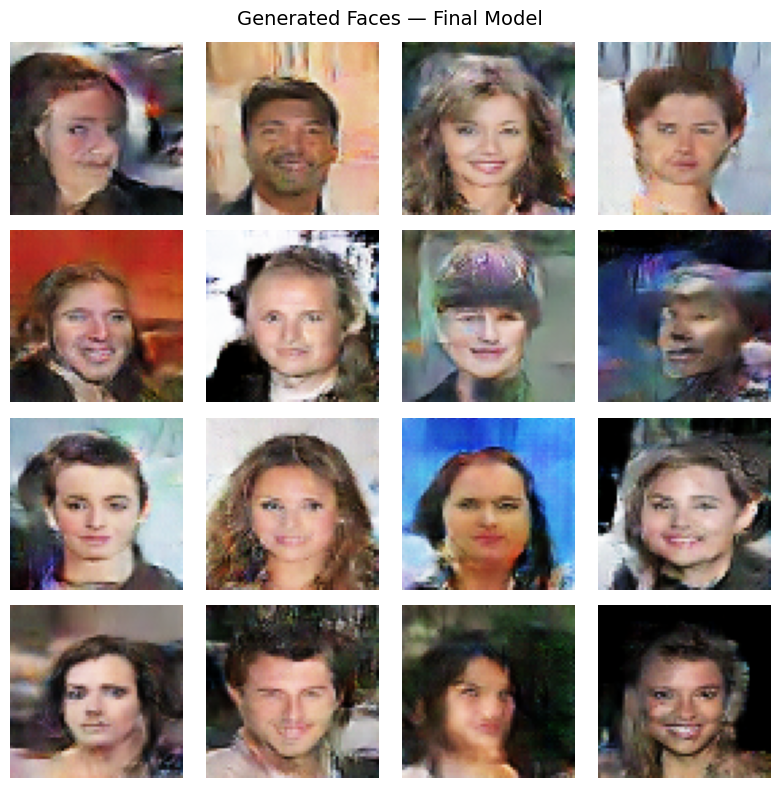

In [16]:

final_model = tf.keras.models.load_model(
    os.path.join(MODEL_DIR, "generator_final.keras")
)

noise = tf.random.normal([16, Z_DIM])
imgs  = (final_model(noise, training=False).numpy() + 1.0) / 2.0
imgs  = np.clip(imgs, 0.0, 1.0)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle("Generated Faces — Final Model", fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "final_generated.png"), dpi=150)
plt.show()